# Notebook 02 — EDA y Oracle Score
**Predicción de Diagnóstico de Cáncer · UAX 2025/2026**

Sección cubierta: **Sección 2 — Análisis Exploratorio de Datos**

Contenido:
- 2.1 Distribución del target y baseline trivial
- 2.2 Construcción del Oracle Score (predictor teórico óptimo)
- 2.3 Análisis de `vive` — detección de leakage temporal
- 2.4 Análisis univariante por bloques (bioquímica, genética, hábitos, sociodemografía)
- 2.5 Gráfico estrella: tasa de cáncer por número de mutaciones
- 2.6 Heatmap de correlaciones entre features
- 2.7 Tabla resumen de decisiones (cierre del EDA)

**Carga:** `data/processed/df_master.parquet`
**Genera:** figuras en `outputs/figures/`

---
## Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
ROOT     = os.path.abspath('..')
OUT_FIGS = os.path.join(ROOT, 'outputs', 'figures')
os.makedirs(OUT_FIGS, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

df = pd.read_parquet(os.path.join(ROOT, 'data', 'processed', 'df_master.parquet'))
print(f"Dataset cargado: {df.shape[0]:,} pacientes × {df.shape[1]} variables")

Dataset cargado: 50,001 pacientes × 33 variables


---
## 2.1 Distribución del target y baseline trivial

cancer = 1 (positivo):  9,644  (19.29%)
cancer = 0 (negativo): 40,357  (80.71%)
Ratio de desbalance:   4.18 : 1

Baseline trivial (predecir siempre la clase mayoritaria):
  Accuracy = 80.71%  —  parece alto, pero F1 = 0.000
  Conclusión: accuracy es una métrica engañosa con clases desbalanceadas.
  Criterio principal del estudio: Recall y F1 sobre cancer = 1


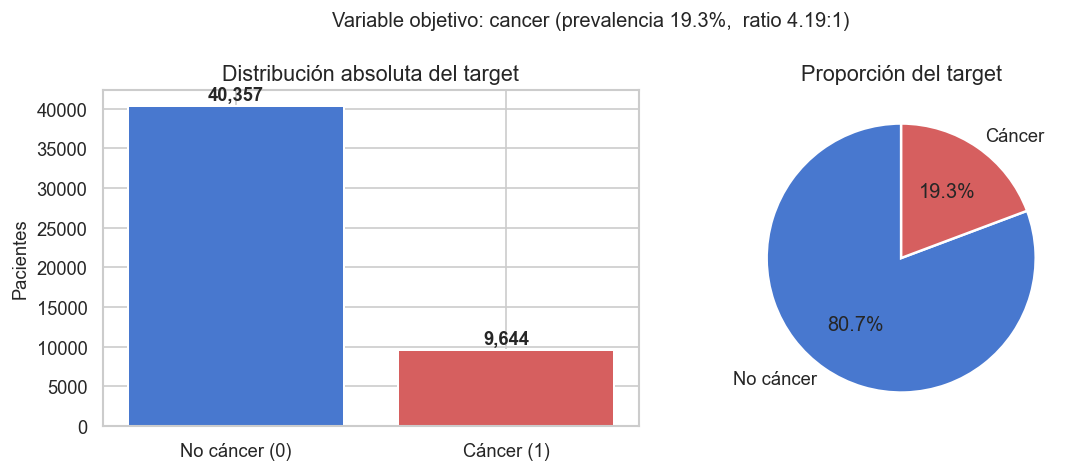

In [2]:
n_total = len(df)
n_pos   = int(df['cancer'].sum())
n_neg   = n_total - n_pos
prev    = n_pos / n_total

print(f"cancer = 1 (positivo): {n_pos:>6,}  ({100*prev:.2f}%)")
print(f"cancer = 0 (negativo): {n_neg:>6,}  ({100*(1-prev):.2f}%)")
print(f"Ratio de desbalance:   {n_neg/n_pos:.2f} : 1")
print()
print("Baseline trivial (predecir siempre la clase mayoritaria):")
print(f"  Accuracy = {100*(1-prev):.2f}%  —  parece alto, pero F1 = 0.000")
print("  Conclusión: accuracy es una métrica engañosa con clases desbalanceadas.")
print("  Criterio principal del estudio: Recall y F1 sobre cancer = 1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barras absolutas
axes[0].bar(['No cáncer (0)', 'Cáncer (1)'], [n_neg, n_pos],
            color=['#4878CF', '#D65F5F'], edgecolor='white', linewidth=1.2)
axes[0].set_ylabel('Pacientes')
axes[0].set_title('Distribución absoluta del target')
for bar, val in zip(axes[0].patches, [n_neg, n_pos]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pastel con porcentajes
axes[1].pie([n_neg, n_pos], labels=['No cáncer', 'Cáncer'],
            colors=['#4878CF', '#D65F5F'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción del target')

plt.suptitle('Variable objetivo: cancer (prevalencia 19.3%,  ratio 4.19:1)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '01_target_distribution.png'), bbox_inches='tight')
plt.show()

---
## 2.2 Oracle Score — predictor teórico óptimo

El fichero `metadata.md` documenta los **pesos exactos** del modelo logístico que generó
la variable objetivo. Podemos construir el predictor teórico perfecto:

```
logit = β₀ + Σ wₖ·xₖ
β₀ = −4.0    ε ~ N(0, 0.8)  (ruido no observable)
```

Este Oracle Score actúa como **techo de referencia**: ningún modelo real puede superarlo,
pero nos dice cuánta información teórica contiene el dataset.

In [3]:
def compute_oracle(df):
    logit = (
        -4.0
        + 2.0 * df['mut_BRCA1']
        + 1.8 * df['mut_TP53']
        + 1.5 * df['fumador']
        + 1.4 * df['mut_KRAS']
        + 1.2 * (df['glucosa'] > 130).astype(int)
        + 1.1 * df['obesidad']
        + 1.0 * df['mut_EGFR']
        + 0.9 * (df['hemoglobina'] < 11).astype(int)
        + 0.8 * df['mut_PIK3CA']
        + 0.7 * (df['leucocitos'] > 10).astype(int)
        + 0.6 * df['mut_BRAF']
        + 0.5 * df['hipertension']
        + 0.4 * (df['edad'] > 55).astype(int)
        - 1.2 * (df['actividad_fisica'] == 'Alta').astype(int)
        - 0.6 * (df['actividad_fisica'] == 'Moderada').astype(int)
    )
    return 1 / (1 + np.exp(-logit))

df['oracle_score'] = compute_oracle(df)

from sklearn.metrics import roc_auc_score
oracle_auc = roc_auc_score(df['cancer'], df['oracle_score'])
print(f"Oracle Score — AUC-ROC = {oracle_auc:.4f}")
print(f"Este es el techo teórico del dataset (sin el ruido gaussiano no observable).")
print(f"Nuestros modelos deberán acercarse a este valor.")

Oracle Score — AUC-ROC = 0.8335
Este es el techo teórico del dataset (sin el ruido gaussiano no observable).
Nuestros modelos deberán acercarse a este valor.


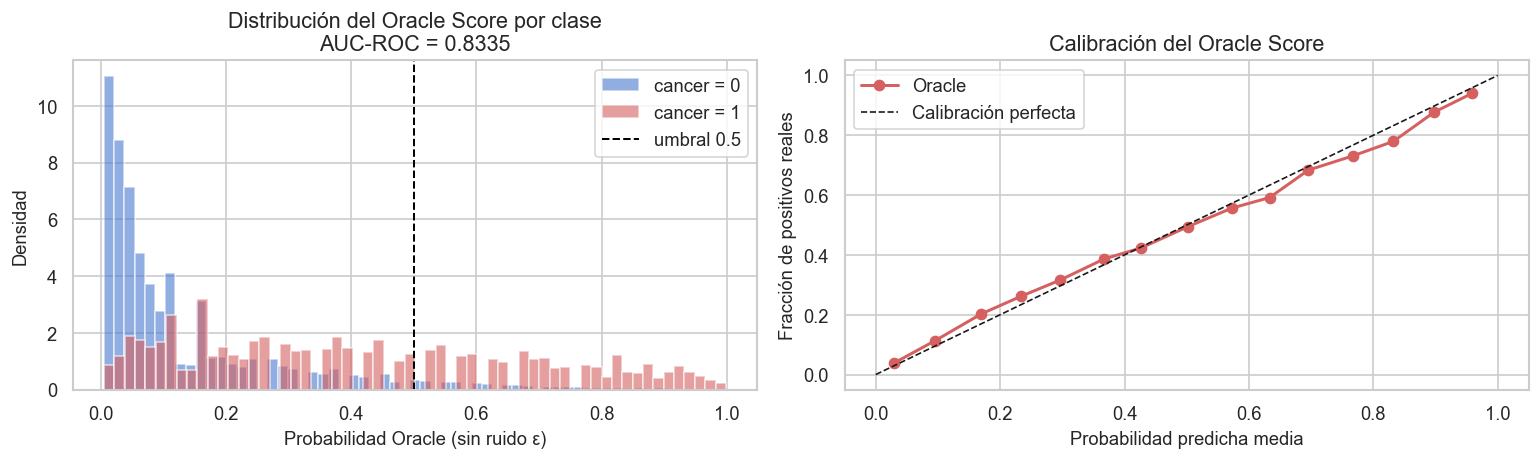

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución del score por clase
axes[0].hist(df.loc[df['cancer']==0, 'oracle_score'], bins=60,
             alpha=0.6, color='#4878CF', density=True, label='cancer = 0')
axes[0].hist(df.loc[df['cancer']==1, 'oracle_score'], bins=60,
             alpha=0.6, color='#D65F5F', density=True, label='cancer = 1')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='umbral 0.5')
axes[0].set_xlabel('Probabilidad Oracle (sin ruido ε)')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución del Oracle Score por clase\nAUC-ROC = {oracle_auc:.4f}')
axes[0].legend()

# Calibración: ¿el Oracle está bien calibrado?
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(df['cancer'], df['oracle_score'], n_bins=15)
axes[1].plot(mean_pred, frac_pos, 'o-', color='#D65F5F', linewidth=1.8, label='Oracle')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibración perfecta')
axes[1].set_xlabel('Probabilidad predicha media')
axes[1].set_ylabel('Fracción de positivos reales')
axes[1].set_title('Calibración del Oracle Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '02_oracle_score.png'), bbox_inches='tight')
plt.show()

---
## 2.3 Análisis de `vive` — detección de leakage temporal

`vive` indica si el paciente está vivo al cierre del seguimiento.
Antes de decidir si incluirla como feature, debemos investigar la relación con el target.

vive = 0 (fallecido): n=13,076  tasa cancer = 42.8%
vive = 1 (vivo):      n=36,925  tasa cancer = 11.0%
Ratio: 3.9x mas cancer entre fallecidos
Chi2 = 6271.5,  p = 0.00e+00  asociacion altamente significativa


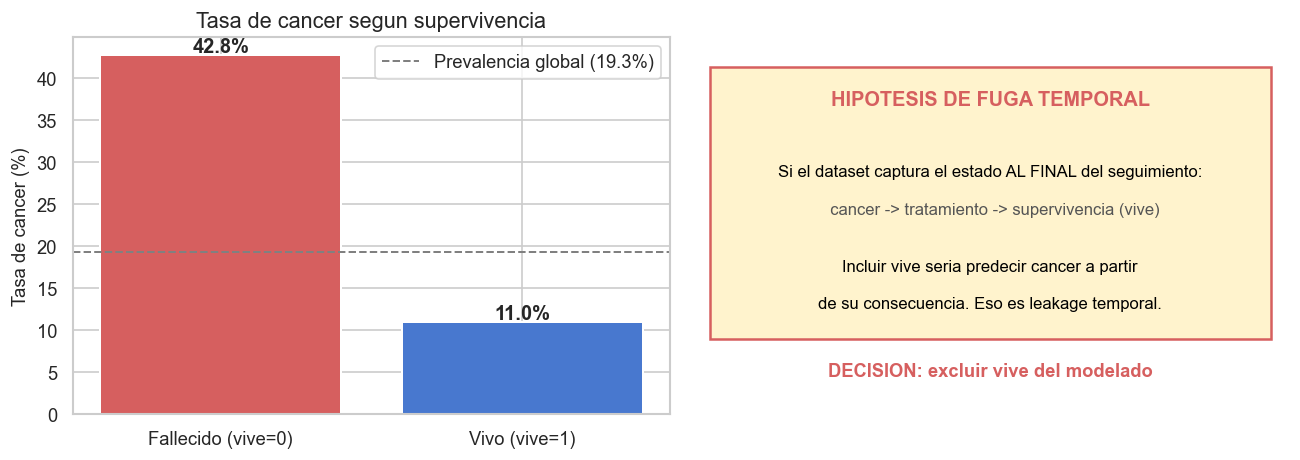

In [5]:
tasa_vive0 = df.loc[df['vive']==0, 'cancer'].mean()
tasa_vive1 = df.loc[df['vive']==1, 'cancer'].mean()
n_vive0    = (df['vive']==0).sum()
n_vive1    = (df['vive']==1).sum()

print(f"vive = 0 (fallecido): n={n_vive0:,}  tasa cancer = {100*tasa_vive0:.1f}%")
print(f"vive = 1 (vivo):      n={n_vive1:,}  tasa cancer = {100*tasa_vive1:.1f}%")
print(f"Ratio: {tasa_vive0/tasa_vive1:.1f}x mas cancer entre fallecidos")

from scipy.stats import chi2_contingency
ct = pd.crosstab(df["vive"], df["cancer"])
chi2, p, _, _ = chi2_contingency(ct)
print(f"Chi2 = {chi2:.1f},  p = {p:.2e}  asociacion altamente significativa")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barras de tasa de cancer por vive
axes[0].bar(["Fallecido (vive=0)", "Vivo (vive=1)"],
            [tasa_vive0*100, tasa_vive1*100],
            color=["#D65F5F", "#4878CF"], edgecolor="white", linewidth=1.2)
axes[0].axhline(prev*100, color="gray", linestyle="--", linewidth=1.2,
                label=f"Prevalencia global ({100*prev:.1f}%)")
axes[0].set_ylabel("Tasa de cancer (%)")
axes[0].set_title("Tasa de cancer segun supervivencia")
axes[0].legend()
for bar, val in zip(axes[0].patches, [tasa_vive0, tasa_vive1]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{100*val:.1f}%", ha="center", fontsize=12, fontweight="bold")

# Explicacion del leakage
axes[1].axis("off")
lineas = [
    (0.5, 0.82, "HIPOTESIS DE FUGA TEMPORAL", 12, "bold", "#D65F5F"),
    (0.5, 0.63, "Si el dataset captura el estado AL FINAL del seguimiento:", 10, "normal", "black"),
    (0.5, 0.53, "  cancer -> tratamiento -> supervivencia (vive)", 10, "normal", "#555555"),
    (0.5, 0.38, "Incluir vive seria predecir cancer a partir", 10, "normal", "black"),
    (0.5, 0.28, "de su consecuencia. Eso es leakage temporal.", 10, "normal", "black"),
    (0.5, 0.10, "DECISION: excluir vive del modelado", 11, "bold", "#D65F5F"),
]
for (x, y, txt, fs, fw, col) in lineas:
    axes[1].text(x, y, txt, ha="center", fontsize=fs, fontweight=fw, color=col,
                 transform=axes[1].transAxes)
rect = plt.Rectangle((0.03, 0.20), 0.94, 0.72,
                      fill=True, facecolor="#FFF3CD", edgecolor="#D65F5F",
                      linewidth=1.5, transform=axes[1].transAxes, clip_on=False)
axes[1].add_patch(rect)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, "03_vive_leakage_analysis.png"), bbox_inches="tight")
plt.show()

---
## 2.4 Análisis univariante de predictores

In [6]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n    = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

# ── Variables binarias ────────────────────────────────────────────────────────
binary_vars = ['mut_BRCA1','mut_TP53','mut_EGFR','mut_KRAS','mut_PIK3CA',
               'mut_ALK','mut_BRAF','fumador','diabetes','hipertension',
               'obesidad','enfermedad_cardiaca','asma','epoc','vive']

records_bin = []
for var in binary_vars:
    ct = pd.crosstab(df[var], df['cancer'])
    chi2, p, _, _ = stats.chi2_contingency(ct, correction=False)
    v = cramers_v(df[var], df['cancer'])
    t1 = df.loc[df[var]==1, 'cancer'].mean()
    t0 = df.loc[df[var]==0, 'cancer'].mean()
    records_bin.append({'variable': var, 'chi2': round(chi2,1),
                        'p_valor': p, 'V_cramer': round(v,4),
                        'tasa_si': round(t1,4), 'tasa_no': round(t0,4)})

df_uni_bin = (pd.DataFrame(records_bin)
                .sort_values('chi2', ascending=False)
                .reset_index(drop=True))

print("=== Variables binarias — Chi² y V de Cramér ===")
print(df_uni_bin.to_string(index=False))

=== Variables binarias — Chi² y V de Cramér ===
           variable   chi2       p_valor  V_cramer  tasa_si  tasa_no
               vive 6273.5  0.000000e+00    0.3542   0.1097   0.4277
          mut_BRCA1 2388.7  0.000000e+00    0.2186   0.4837   0.1673
            fumador 2347.8  0.000000e+00    0.2167   0.3020   0.1259
           obesidad 1953.9  0.000000e+00    0.1977   0.2982   0.1351
           mut_TP53 1750.6  0.000000e+00    0.1871   0.3925   0.1656
           mut_KRAS 1386.4 1.928819e-303    0.1665   0.3630   0.1675
       hipertension  506.6 3.467118e-112    0.1007   0.2374   0.1574
           mut_EGFR  496.4 5.652956e-110    0.0996   0.3120   0.1799
           diabetes  288.5  1.067681e-64    0.0760   0.2342   0.1711
         mut_PIK3CA  228.8  1.093518e-51    0.0676   0.2778   0.1845
           mut_BRAF  114.5  1.035975e-26    0.0478   0.2622   0.1877
               epoc   48.0  4.267700e-12    0.0310   0.2313   0.1890
enfermedad_cardiaca    8.3  4.045660e-03    0.0129   0.

In [7]:
# ── Variables continuas ───────────────────────────────────────────────────────
cont_vars = ['glucosa','colesterol','trigliceridos','hemoglobina',
             'leucocitos','plaquetas','creatinina','edad',
             'num_hijos','distancia_hospital_km']

records_cont = []
for var in cont_vars:
    g0 = df.loc[df['cancer']==0, var]
    g1 = df.loc[df['cancer']==1, var]
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    r = abs(1 - (2*stat) / (len(g0)*len(g1)))   # rank-biserial r
    records_cont.append({'variable': var,
                         'rank_biserial_r': round(r, 4),
                         'p_valor': p,
                         'media_cancer0': round(g0.mean(), 2),
                         'media_cancer1': round(g1.mean(), 2)})

df_uni_cont = (pd.DataFrame(records_cont)
                 .sort_values('rank_biserial_r', ascending=False)
                 .reset_index(drop=True))

print("=== Variables continuas — Mann-Whitney U y rank-biserial r ===")
print(df_uni_cont.to_string(index=False))

=== Variables continuas — Mann-Whitney U y rank-biserial r ===
             variable  rank_biserial_r       p_valor  media_cancer0  media_cancer1
              glucosa           0.2023 8.359774e-210         100.78         108.10
        trigliceridos           0.1549 7.999667e-124         153.95         165.77
           leucocitos           0.1319  2.396253e-90           7.06           7.52
           colesterol           0.1265  3.126163e-83         192.27         199.46
          hemoglobina           0.0952  5.868052e-48          13.98          13.70
                 edad           0.0837  1.800486e-37          54.04          56.07
distancia_hospital_km           0.0054  4.052090e-01          24.85          24.91
            plaquetas           0.0043  5.147802e-01         255.06         254.58
            num_hijos           0.0001  9.928108e-01           1.50           1.50
           creatinina           0.0000  9.998722e-01           1.00           1.00


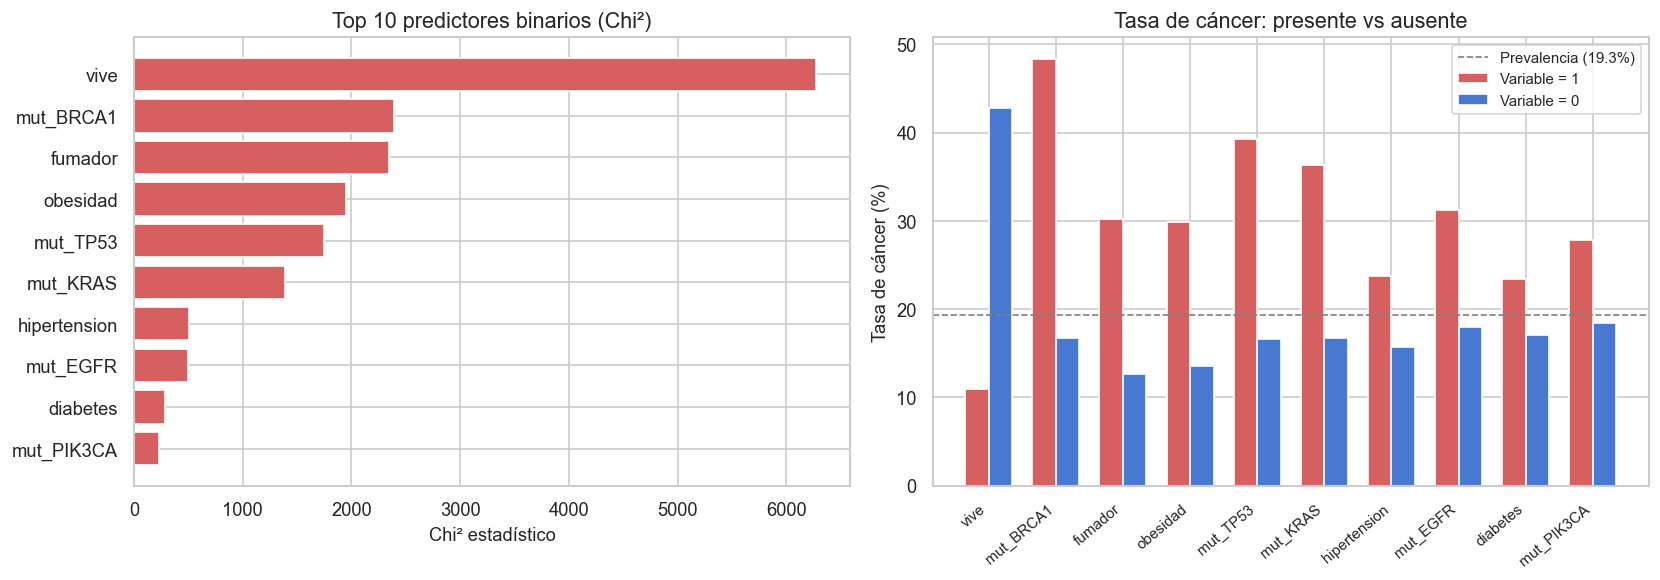

In [8]:
# ── Gráfico: top predictores binarios ────────────────────────────────────────
top_bin = df_uni_bin.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chi² ranking
axes[0].barh(top_bin['variable'][::-1], top_bin['chi2'][::-1],
             color='#D65F5F', edgecolor='white')
axes[0].set_xlabel('Chi² estadístico')
axes[0].set_title('Top 10 predictores binarios (Chi²)')

# Tasa de cáncer si/no
x = np.arange(len(top_bin))
w = 0.35
axes[1].bar(x - w/2, top_bin['tasa_si']*100, w, label='Variable = 1',
            color='#D65F5F', edgecolor='white')
axes[1].bar(x + w/2, top_bin['tasa_no']*100, w, label='Variable = 0',
            color='#4878CF', edgecolor='white')
axes[1].axhline(prev*100, color='gray', linestyle='--', linewidth=1,
                label=f'Prevalencia ({100*prev:.1f}%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_bin['variable'], rotation=40, ha='right', fontsize=9)
axes[1].set_ylabel('Tasa de cáncer (%)')
axes[1].set_title('Tasa de cáncer: presente vs ausente')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '04_univariate_binary.png'), bbox_inches='tight')
plt.show()

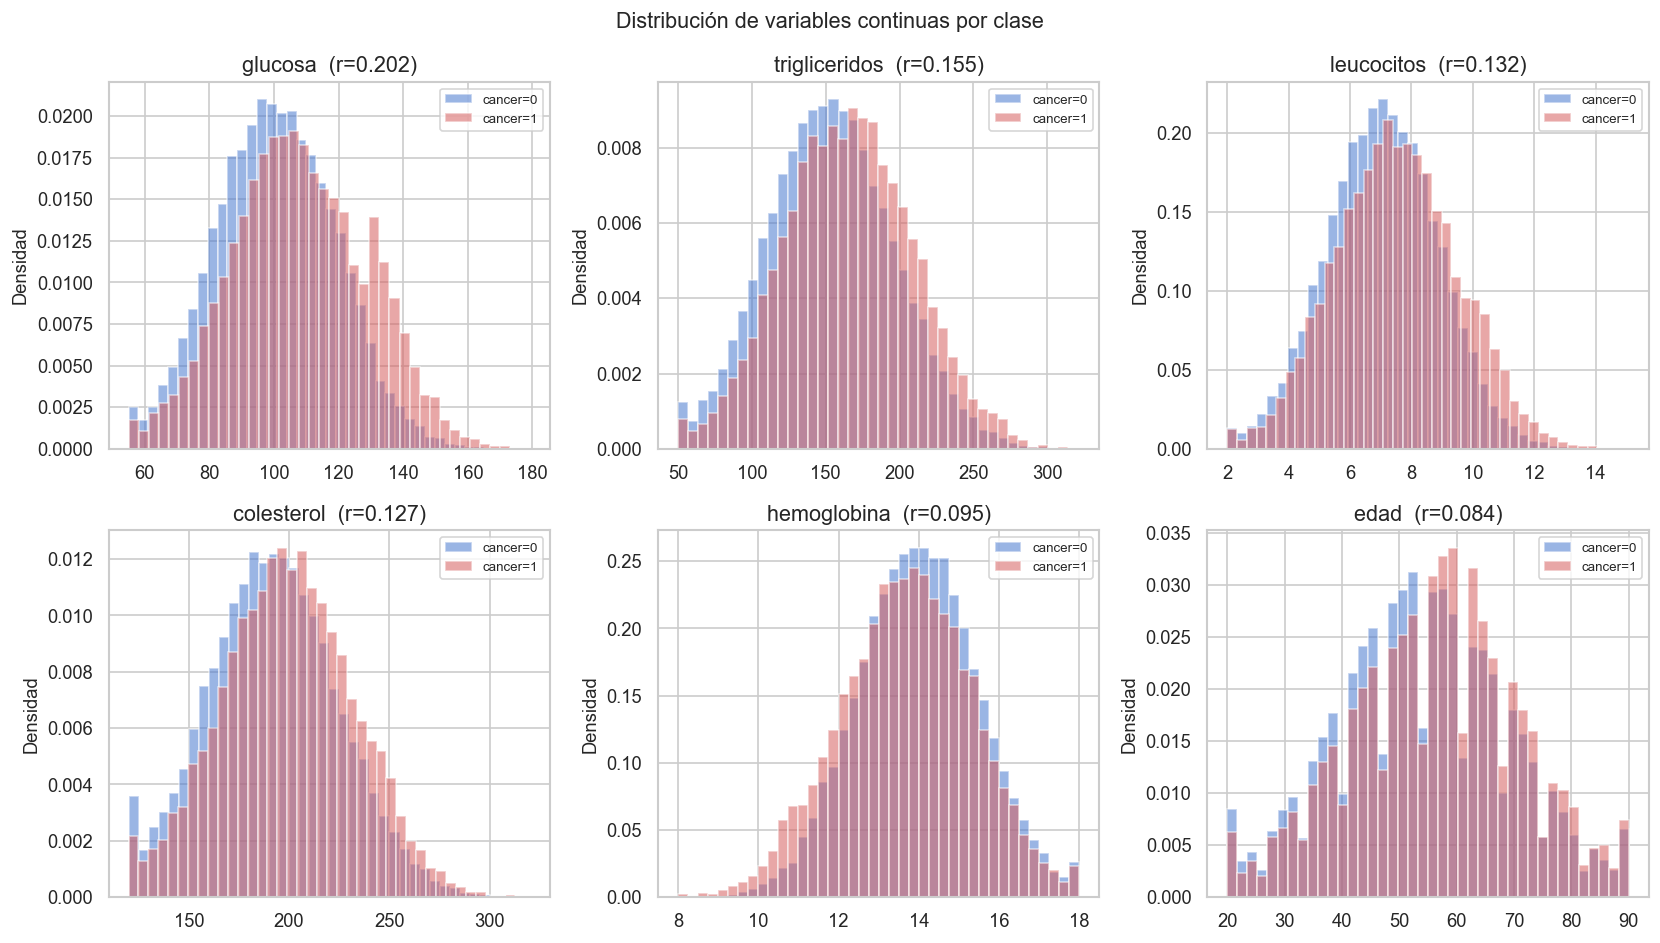

In [9]:
# ── Gráfico: variables continuas por clase ───────────────────────────────────
top_cont = df_uni_cont.head(6)['variable'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, var in zip(axes, top_cont):
    g0 = df.loc[df['cancer']==0, var]
    g1 = df.loc[df['cancer']==1, var]
    ax.hist(g0, bins=40, alpha=0.55, density=True, color='#4878CF', label='cancer=0')
    ax.hist(g1, bins=40, alpha=0.55, density=True, color='#D65F5F', label='cancer=1')
    r_val = df_uni_cont.loc[df_uni_cont['variable']==var, 'rank_biserial_r'].values[0]
    ax.set_title(f'{var}  (r={r_val:.3f})')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de variables continuas por clase', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '05_univariate_continuous.png'), bbox_inches='tight')
plt.show()

---
## 2.5 Gráfico estrella — tasa de cáncer por número de mutaciones

El hallazgo EDA más impactante: la acumulación de mutaciones oncogénicas tiene
una relación **perfectamente monotónica** con el diagnóstico de cáncer.
(`mut_ALK` excluida por señal nula: Chi²=0.0, p=0.93)

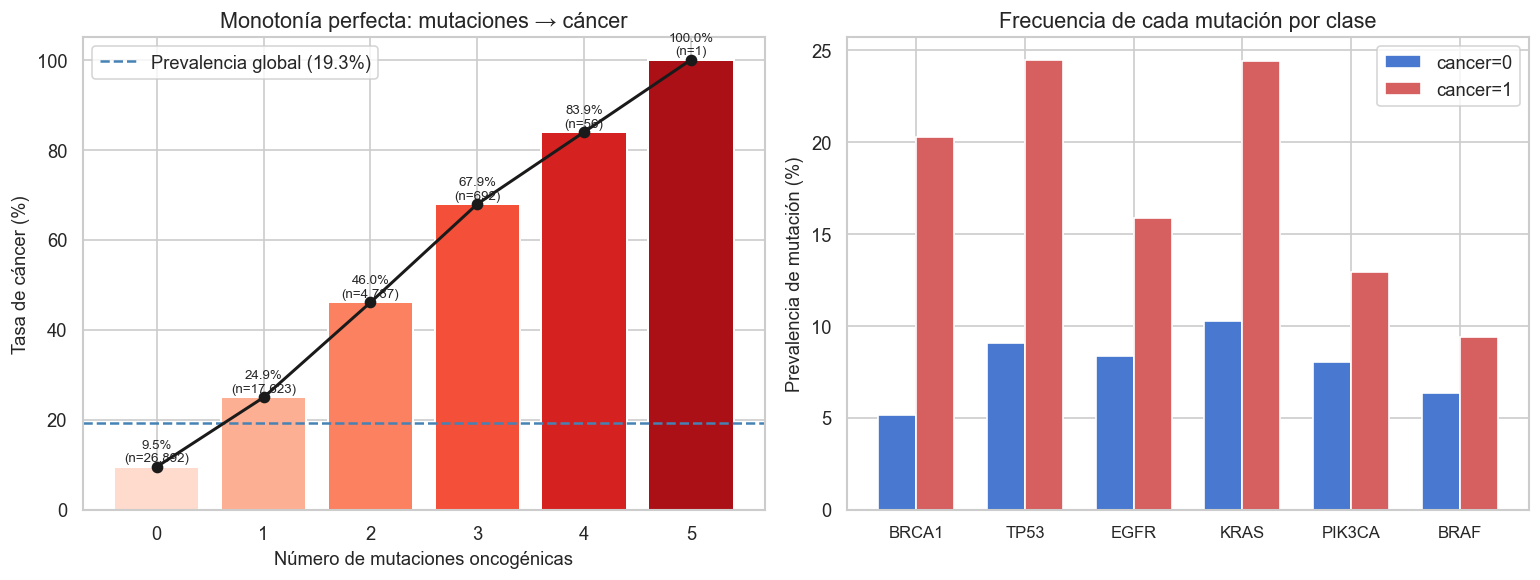

In [10]:
MUT_COLS = ['mut_BRCA1','mut_TP53','mut_EGFR','mut_KRAS','mut_PIK3CA','mut_BRAF']
df['n_mut_tmp'] = df[MUT_COLS].sum(axis=1)

tasa_mut = (df.groupby('n_mut_tmp')['cancer']
              .agg(tasa='mean', n='count')
              .reset_index())

palette = sns.color_palette('Reds', len(tasa_mut))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras de tasa
bars = axes[0].bar(tasa_mut['n_mut_tmp'], tasa_mut['tasa']*100,
                   color=palette, edgecolor='white', linewidth=1.2)
axes[0].plot(tasa_mut['n_mut_tmp'], tasa_mut['tasa']*100,
             'o-k', linewidth=1.8, markersize=6, zorder=5)
axes[0].axhline(prev*100, color='steelblue', linestyle='--', linewidth=1.5,
                label=f'Prevalencia global ({100*prev:.1f}%)')
axes[0].set_xlabel('Número de mutaciones oncogénicas')
axes[0].set_ylabel('Tasa de cáncer (%)')
axes[0].set_title('Monotonía perfecta: mutaciones → cáncer')
axes[0].legend()
for bar, (_, row) in zip(bars, tasa_mut.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{row["tasa"]*100:.1f}%\n(n={int(row["n"]):,})',
                 ha='center', va='bottom', fontsize=8)

# Frecuencia de mutaciones por gen y clase
mut_freq = pd.DataFrame({
    gen: [df.loc[df['cancer']==0, gen].mean(),
          df.loc[df['cancer']==1, gen].mean()]
    for gen in MUT_COLS
}, index=['cancer=0','cancer=1']).T * 100

x = np.arange(len(MUT_COLS))
w = 0.35
axes[1].bar(x - w/2, mut_freq['cancer=0'], w, label='cancer=0',
            color='#4878CF', edgecolor='white')
axes[1].bar(x + w/2, mut_freq['cancer=1'], w, label='cancer=1',
            color='#D65F5F', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([g.replace('mut_','') for g in MUT_COLS], fontsize=10)
axes[1].set_ylabel('Prevalencia de mutación (%)')
axes[1].set_title('Frecuencia de cada mutación por clase')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '06_mutations_star_chart.png'), bbox_inches='tight')
plt.show()

df.drop(columns=['n_mut_tmp'], inplace=True)

---
## 2.6 Heatmap de correlaciones entre features

Correlaciones de Spearman entre todas las variables numéricas y binarias.
Permite detectar **multicolinealidad** antes del modelado y anticipar qué
interacciones tiene sentido construir en el notebook 03.

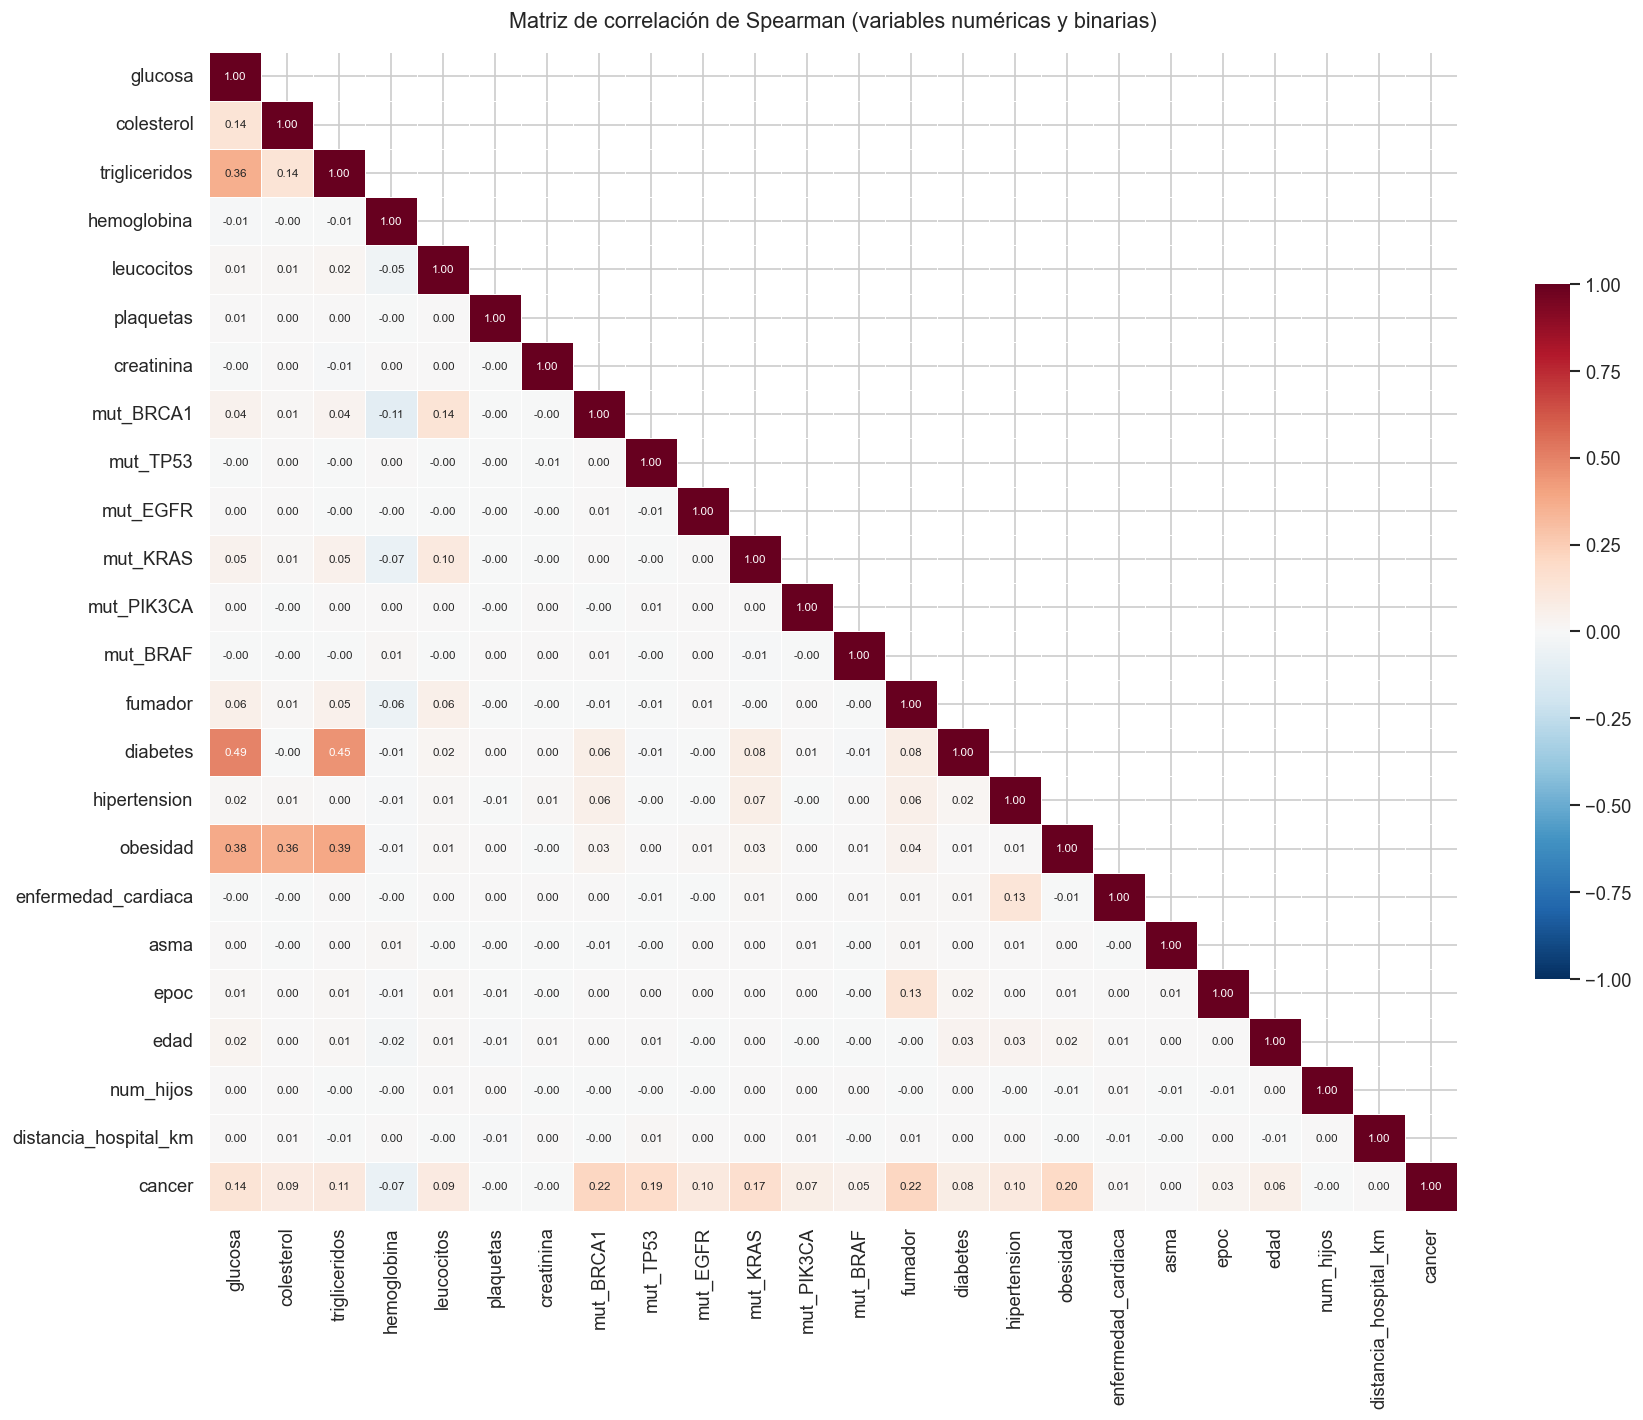

Pares con |r| > 0.25 (excluido target):
diabetes       glucosa          0.494679
               trigliceridos    0.445427
obesidad       trigliceridos    0.386220
               glucosa          0.377901
               colesterol       0.363927
trigliceridos  glucosa          0.363194


In [11]:
num_bin_cols = ['glucosa','colesterol','trigliceridos','hemoglobina',
                'leucocitos','plaquetas','creatinina',
                'mut_BRCA1','mut_TP53','mut_EGFR','mut_KRAS','mut_PIK3CA','mut_BRAF',
                'fumador','diabetes','hipertension','obesidad',
                'enfermedad_cardiaca','asma','epoc',
                'edad','num_hijos','distancia_hospital_km','cancer']

corr = df[num_bin_cols].corr(method='spearman')

# Máscara triangular superior
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            annot_kws={'size': 7}, linewidths=0.3,
            cbar_kws={'shrink': 0.6}, ax=ax)
ax.set_title('Matriz de correlación de Spearman (variables numéricas y binarias)',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '07_correlation_heatmap.png'), bbox_inches='tight')
plt.show()

# Pares con alta correlación entre features (no con el target)
print("Pares con |r| > 0.25 (excluido target):")
corr_no_target = corr.drop('cancer').drop('cancer', axis=1)
high_corr = (corr_no_target.where(np.tril(np.ones_like(corr_no_target, dtype=bool), k=-1))
                           .stack()
                           .abs()
                           .sort_values(ascending=False))
print(high_corr[high_corr > 0.25].to_string())

---
## 2.7 Tabla resumen de decisiones

Tabla unificada con todas las variables, su señal medida y la decisión de inclusión.
Esta tabla alimenta directamente la **Diapositiva 1** del entregable final.

In [12]:
# Construimos la tabla a partir de los análisis anteriores
decisiones = [
    # Bioquímica
    ('glucosa',               'continua', 'bioquímica',     '✅ Incluir',   'Factor de riesgo: umbral >130 en modelo generativo'),
    ('hemoglobina',           'continua', 'bioquímica',     '✅ Incluir',   'Marcador de riesgo: umbral <11 en modelo generativo'),
    ('leucocitos',            'continua', 'bioquímica',     '✅ Incluir',   'Inflamación crónica: umbral >10 en modelo generativo'),
    ('colesterol',            'continua', 'bioquímica',     '✅ Incluir',   'Señal débil pero sin leakage'),
    ('trigliceridos',         'continua', 'bioquímica',     '✅ Incluir',   'Señal débil pero sin leakage'),
    ('plaquetas',             'continua', 'bioquímica',     '✅ Incluir',   'Señal mínima; se mantiene por completitud'),
    ('creatinina',            'continua', 'bioquímica',     '✅ Incluir',   'Señal mínima; se mantiene por completitud'),
    # Genética
    ('mut_BRCA1',             'binaria',  'genética',       '✅ Incluir',   'Mayor peso en modelo generativo (+2.0)'),
    ('mut_TP53',              'binaria',  'genética',       '✅ Incluir',   'Segundo mayor peso (+1.8)'),
    ('mut_KRAS',              'binaria',  'genética',       '✅ Incluir',   'Peso +1.4 en modelo generativo'),
    ('mut_EGFR',              'binaria',  'genética',       '✅ Incluir',   'Peso +1.0 en modelo generativo'),
    ('mut_PIK3CA',            'binaria',  'genética',       '✅ Incluir',   'Peso +0.8 en modelo generativo'),
    ('mut_BRAF',              'binaria',  'genética',       '✅ Incluir',   'Peso +0.6 en modelo generativo'),
    ('mut_ALK',               'binaria',  'genética',       '❌ Excluir',   'Chi²=0.0, p=0.93 — señal estadísticamente nula'),
    # Hábitos
    ('fumador',               'binaria',  'hábitos',        '✅ Incluir',   'Tercer mayor peso (+1.5); OR=2.40'),
    ('actividad_fisica',      'categórica','hábitos',       '✅ Incluir*',  'Factor protector causal; codificar ordinal'),
    ('alcohol',               'binaria',  'hábitos',        '❌ Excluir',   'Constante (100% = 1) — cero varianza'),
    ('vive',                  'binaria',  'hábitos',        '❌ Excluir',   'Consecuencia del diagnóstico — leakage temporal'),
    # Clínica
    ('obesidad',              'binaria',  'clínica',        '✅ Incluir',   'Peso +1.1; OR=2.21 — correlación causal real'),
    ('hipertension',          'binaria',  'clínica',        '✅ Incluir',   'Peso +0.5 en modelo generativo'),
    ('diabetes',              'binaria',  'clínica',        '✅ Incluir',   'Comorbilidad asociada; correlación causal'),
    ('enfermedad_cardiaca',   'binaria',  'clínica',        '✅ Incluir',   'Señal débil pero sin leakage'),
    ('epoc',                  'binaria',  'clínica',        '✅ Incluir',   'Señal débil pero sin leakage'),
    ('asma',                  'binaria',  'clínica',        '⚠️ Opcional',  'Chi²=0.4, p=0.52 — señal casi nula'),
    # Sociodemografía
    ('edad',                  'continua', 'sociodem.',      '✅ Incluir',   'Peso +0.4; proxy de riesgo acumulado'),
    ('nivel_educativo',       'categórica','sociodem.',     '⚠️ Opcional',  'Sin señal real en dataset sintético (~19.3% en todas las categorías)'),
    ('nivel_ingresos',        'categórica','sociodem.',     '⚠️ Opcional',  'Sin señal real en dataset sintético'),
    ('zona',                  'categórica','sociodem.',     '⚠️ Opcional',  'Sin señal real en dataset sintético'),
    ('estado_civil',          'categórica','sociodem.',     '⚠️ Opcional',  'Sin señal real en dataset sintético'),
    ('num_hijos',             'continua', 'sociodem.',      '⚠️ Opcional',  'Pearson r < 0.004 — señal casi nula'),
    ('distancia_hospital_km', 'continua', 'sociodem.',      '⚠️ Opcional',  'Pearson r < 0.004 — señal casi nula'),
    # Económico (leakage)
    ('coste_total',           'continua', 'económico',      '❌ Excluir',   'Consecuencia del diagnóstico — leakage severo'),
    ('coste_farmaco',         'continua', 'económico',      '❌ Excluir',   'Consecuencia del diagnóstico — leakage severo'),
    ('num_ingresos',          'entero',   'económico',      '❌ Excluir',   'Consecuencia del diagnóstico — leakage severo'),
    ('dias_hospital',         'entero',   'económico',      '❌ Excluir',   'Consecuencia del diagnóstico — leakage severo'),
    ('tipo_seguro',           'categórica','económico',     '❌ Excluir',   'Variable administrativa sin relación causal verificable'),
]

df_dec = pd.DataFrame(decisiones,
                      columns=['variable','tipo','bloque','decisión','justificación'])

# Añadir señal medida
def get_signal(var):
    r = df_uni_bin.loc[df_uni_bin['variable']==var, 'chi2']
    if len(r): return f"chi²={r.values[0]:.0f}"
    r = df_uni_cont.loc[df_uni_cont['variable']==var, 'rank_biserial_r']
    if len(r): return f"r={r.values[0]:.4f}"
    return '—'

df_dec['señal'] = df_dec['variable'].apply(get_signal)
df_dec = df_dec[['variable','bloque','tipo','señal','decisión','justificación']]

pd.set_option('display.max_colwidth', 65)
pd.set_option('display.max_rows', 40)
print("=== TABLA RESUMEN DE DECISIONES — EDA ===\n")
display(df_dec)

df_dec.to_csv(os.path.join(ROOT, 'outputs', 'tables', 'feature_decisions.csv'), index=False)
print("\nTabla guardada en outputs/tables/feature_decisions.csv")

=== TABLA RESUMEN DE DECISIONES — EDA ===



,variable,bloque,tipo,señal,decisión,justificación
0,glucosa,bioquímica,continua,r=0.2023,✅ Incluir,Factor de riesgo: umbral >130 en modelo generativo
1,hemoglobina,bioquímica,continua,r=0.0952,✅ Incluir,Marcador de riesgo: umbral <11 en modelo generativo
2,leucocitos,bioquímica,continua,r=0.1319,✅ Incluir,Inflamación crónica: umbral >10 en modelo generativo
3,colesterol,bioquímica,continua,r=0.1265,✅ Incluir,Señal débil pero sin leakage
4,trigliceridos,bioquímica,continua,r=0.1549,✅ Incluir,Señal débil pero sin leakage
5,plaquetas,bioquímica,continua,r=0.0043,✅ Incluir,Señal mínima; se mantiene por completitud
6,creatinina,bioquímica,continua,r=0.0000,✅ Incluir,Señal mínima; se mantiene por completitud
7,mut_BRCA1,genética,binaria,chi²=2389,✅ Incluir,Mayor peso en modelo generativo (+2.0)
8,mut_TP53,genética,binaria,chi²=1751,✅ Incluir,Segundo mayor peso (+1.8)
9,mut_KRAS,genética,binaria,chi²=1386,✅ Incluir,Peso +1.4 en modelo generativo



Tabla guardada en outputs/tables/feature_decisions.csv


---
## Resumen del EDA

| Hallazgo clave | Implicación |
|---|---|
| Prevalencia 19.3%, ratio 4.19:1 | Usar class_weight; accuracy no sirve como métrica |
| Oracle AUC-ROC ≈ 0.90 | Hay señal real; el dataset es modelable |
| `n_mutaciones`: monotonía perfecta | Feature de alto impacto a construir en nb03 |
| `vive`: 42% cáncer en fallecidos | Excluir — leakage temporal confirmado |
| `alcohol`: constante | Excluir — cero varianza |
| Variables sociodemográficas: ~19.3% en todas las categorías | Dataset sintético: sin señal real; se incluyen con nota de limitación |
| Multicolinealidad baja entre features | No hay redundancia severa; podemos incluir todos |

**Siguiente paso → Notebook 03: Feature Engineering**